In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = "3"

In [3]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
from tqdm import tqdm, trange

from datasets import load_dataset
import pandas as pd
import functools
import sys
from pathlib import Path
from typing import Callable

# import circuitsvis as cv
import einops
import numpy as np
import torch as t
import torch.nn as nn
import torch.nn.functional as F
import eindex
# from IPython.display import display
from jaxtyping import Float, Int
from torch import Tensor
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset, Dataset, DatasetDict
from transformers import AutoTokenizer
import os
import json
import matplotlib.pyplot as plt
import math
import seaborn as sns

/home/kokil/shaz/interp-toxicity/interp-toxicity2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
print("Available CUDA devices:", torch.cuda.device_count())
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

Available CUDA devices: 1
Device 0: NVIDIA H100 80GB HBM3


In [5]:
tokenizer  = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2,
    output_attentions=True      # optional
).to(device)
model.eval()
model.load_state_dict(torch.load('toxigen/model_epoch_2_acc_0.8490.pt', map_location=device))

2025-06-16 16:59:32.285049: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-16 16:59:32.298187: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750093172.313105 1916913 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750093172.317389 1916913 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750093172.329347 1916913 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

<All keys matched successfully>

## Patching

In [6]:
import math
import torch
import torch.nn as nn
from contextlib import contextmanager
from tqdm import trange

from transformers import BertModel, BertForSequenceClassification


# ----------------------------------------------------------------------------------------------------------------------
# 1) Helpers: Build a patched forward() that accepts *args, **kwargs
# ----------------------------------------------------------------------------------------------------------------------

def _make_patched_forward(self, head_to_zero: int):
    """
    Returns a function that can be bound to `BertSelfAttention.forward`
    in order to zero out `head_to_zero` right after the Softmax.
    """

    num_heads = self.num_attention_heads
    head_dim   = self.attention_head_size
    all_head_size = self.all_head_size

    def patched_forward(self, *args, **kwargs):
        """
        A drop-in replacement for BertSelfAttention.forward that zeroes one head.
        We expect this to be bound on `self = layer.attention.self`.
        """

        # --------------------------------------------------------------------------------
        # Step 1: Extract the actual arguments from *args and **kwargs
        # --------------------------------------------------------------------------------
        # In HuggingFace v4, the signature is roughly:
        #    def forward(
        #         self,
        #         hidden_states,
        #         attention_mask=None,
        #         head_mask=None,
        #         encoder_hidden_states=None,
        #         encoder_attention_mask=None,
        #         past_key_value=None,
        #         output_attentions=False,
        #         output_hidden_states=False,
        #         return_dict=True,
        #    ):
        #
        # We only care about hidden_states, attention_mask, head_mask, output_attentions for our patch.
        # Everything else we will ignore or pass through as-is when returning.

        # hidden_states is always the first positional argument:
        hidden_states = args[0]

        # The other parameters might come positionally or as keywords. We'll check both.
        attention_mask      = kwargs.get("attention_mask", None)
        head_mask           = kwargs.get("head_mask", None)
        output_attentions   = kwargs.get("output_attentions", False)

        # (We do NOT need encoder_hidden_states, etc., because BERT's BertSelfAttention
        #  does not use them in its own mask + softmax + matmul code path. Those are for cross-attention.)
        #
        # If you have a model where cross-attention is used inside the same class,
        # you would need to pull out encoder_hidden_states/encoder_attention_mask, etc.
        # But for plain BERT, we can ignore them.

        # --------------------------------------------------------------------------------
        # Step 2: Copy HuggingFace's logic up to (and after) softmax
        # --------------------------------------------------------------------------------
        mixed_query_layer = self.query(hidden_states)
        mixed_key_layer   = self.key(hidden_states)
        mixed_value_layer = self.value(hidden_states)
        # At this point: mixed_value_layer has shape (batch_size, seq_len, all_head_size).

        # A helper to reshape (batch, seq_len, all_head_size) → (batch, heads, seq_len, head_dim)
        def transpose_for_scores(x):
            new_shape = x.size()[:-1] + (num_heads, head_dim)
            x = x.view(*new_shape)
            return x.permute(0, 2, 1, 3)  # (batch, heads, seq_len, head_dim)

        query_layer = transpose_for_scores(mixed_query_layer)  # (B, H, S, head_dim)
        key_layer   = transpose_for_scores(mixed_key_layer)    # (B, H, S, head_dim)
        value_layer = transpose_for_scores(mixed_value_layer)  # (B, H, S, head_dim)

        # 1) Compute raw attention scores
        attention_scores = torch.matmul(query_layer, key_layer.transpose(-1, -2))  # (B, H, S, S)
        attention_scores = attention_scores / math.sqrt(head_dim)

        # 2) If there is an attention_mask, add it
        if attention_mask is not None:
            attention_scores = attention_scores + attention_mask

        # 3) Softmax → attention_probs, then dropout
        attention_probs = torch.nn.functional.softmax(attention_scores, dim=-1)
        attention_probs = torch.nn.functional.dropout(
            attention_probs,
            p=self.dropout.p if hasattr(self, "dropout") else 0.1,
            training=self.training
        )

        # --------------------------------------------------------------------------------
        # Step 3: Zero out exactly head_to_zero in attention_probs
        # --------------------------------------------------------------------------------
        # We clone first to avoid in-place side-effects in subsequent layers
        attention_probs = attention_probs.clone()
        attention_probs[:, head_to_zero, :, :] = 0.0

        # --------------------------------------------------------------------------------
        # Step 4: Apply head_mask if provided (same as HF code)
        # --------------------------------------------------------------------------------
        if head_mask is not None:
            attention_probs = attention_probs * head_mask

        # --------------------------------------------------------------------------------
        # Step 5: Compute context = attention_probs @ value_layer
        #          (B, H, S, S)    @ (B, H, S, head_dim) → (B, H, S, head_dim)
        # --------------------------------------------------------------------------------
        context_layer = torch.matmul(attention_probs, value_layer)

        # --------------------------------------------------------------------------------
        # Step 6: Permute / reshape back to (batch, seq_len, all_head_size)
        # --------------------------------------------------------------------------------
        context_layer = context_layer.permute(0, 2, 1, 3).contiguous()  # (B, S, H, head_dim)
        new_context_shape = context_layer.size()[:-2] + (all_head_size,)
        context_layer = context_layer.view(*new_context_shape)  # (B, S, hidden_size)

        # --------------------------------------------------------------------------------
        # Step 7: Build the return object exactly as BertSelfAttention does
        # --------------------------------------------------------------------------------
        outputs = (context_layer, attention_probs) if output_attentions else (context_layer,)
        
        # Finally return `outputs`. We do NOT return anything else (the calling code expects exactly
        # what HF returns: a tuple whose first element is context_layer, and second is attention_probs
        # if output_attentions=True).
        return outputs

    return patched_forward


@contextmanager
def zero_head(model: nn.Module, layer_idx: int, head_idx: int):
    """
    Temporarily patch layer `layer_idx`'s self-attention so that head `head_idx` is zeroed out
    right after the softmax. When we exit the context, we restore the original forward().

    Usage:
        with zero_head(model, layer_idx=0, head_idx=4):
            # Now layer0.head4 is disabled
            out = model(input_ids, attention_mask, labels=labels)
        # After the with-block, head 4 is restored.
    """
    # 1) Grab the BertSelfAttention submodule from the desired encoder layer
    layer_self_attn = model.bert.encoder.layer[layer_idx].attention.self

    # 2) Keep a reference to its original forward
    orig_forward = layer_self_attn.forward

    # 3) Create & bind our patched forward
    patched = _make_patched_forward(layer_self_attn, head_idx)
    layer_self_attn.forward = patched.__get__(layer_self_attn, type(layer_self_attn))

    try:
        yield
    finally:
        # 4) Restore the original forward method
        layer_self_attn.forward = orig_forward


# ----------------------------------------------------------------------------------------------------------------------
# 2) Main function: Compute Δ-loss for each (layer, head)
# ----------------------------------------------------------------------------------------------------------------------

def get_ablation_scores(
    classifier: nn.Module,
    input_ids:     torch.Tensor,
    attention_mask: torch.Tensor,
    labels:        torch.Tensor,
    criterion:     nn.Module,
):
    """
    For every (layer, head), temporarily zero out that head and compute:
        Δ-loss = Loss_with_head_zeroed − Loss_baseline.

    Returns:
      - scores:     torch.Tensor of shape (n_layers, n_heads) containing Δ-loss for each head
      - base_preds: torch.LongTensor of shape (batch_size,) with baseline predictions (no ablation)
      - predictions: dict mapping (layer, head) → torch.LongTensor of shape (batch_size,)
                     containing predictions when that head is zeroed.
    """

    n_layers = classifier.config.num_hidden_layers
    n_heads  = classifier.config.num_attention_heads
    device   = input_ids.device

    # 1) Compute the baseline (no head zeroed) loss & predictions
    classifier.eval()
    with torch.no_grad():
        # We call .forward(...) exactly as usual.
        base_out    = classifier(input_ids=input_ids,
                                 attention_mask=attention_mask,
                                 labels=labels,
                                 output_attentions=False)
        base_loss   = base_out.loss
        base_logits = base_out.logits
        base_preds  = torch.argmax(base_logits, dim=-1)

    # 2) Prepare containers
    scores      = torch.zeros(n_layers, n_heads, device=device)
    predictions = {}

    # 3) Loop over each layer & head
    for L in trange(n_layers, desc="Layers"):
        for H in range(n_heads):
            # Temporarily zero out head H in layer L
            with zero_head(classifier, layer_idx=L, head_idx=H):
                classifier.eval()
                with torch.no_grad():
                    out = classifier(input_ids=input_ids,
                                     attention_mask=attention_mask,
                                     labels=labels,
                                     output_attentions=False)
                    ablated_loss   = out.loss
                    ablated_logits = out.logits
                    ablated_preds  = torch.argmax(ablated_logits, dim=-1)

            # Δ-loss = ablated_loss − base_loss
            scores[L, H] = (ablated_loss - base_loss).detach()
            predictions[(L, H)] = ablated_preds.cpu()

    return scores.cpu(), base_preds.cpu(), predictions

In [67]:
criterion = nn.CrossEntropyLoss()

In [12]:
data = []
with open('pgd_log_toxigen', 'r') as f:
    for line in f:
        if line.strip():  # Skip empty lines
            tmp = json.loads(line)
            data.append(tmp)

In [13]:
len(data)

62737

In [14]:
df = pd.DataFrame(data)

In [56]:
df = pd.read_csv('pgd_log.csv')

In [57]:
from sentence_transformers import SentenceTransformer

emb_model = SentenceTransformer("all-MiniLM-L6-v2")

In [58]:
df.success.value_counts()

success
False    16576
True      4526
Name: count, dtype: int64

In [60]:
embeddings1 = emb_model.encode(df.original_text)
embeddings2 = emb_model.encode(df.perturbed_text)

In [61]:
similarities = emb_model.similarity(embeddings1, embeddings2)

In [62]:
df['similarity'] = similarities.diag().numpy()

(array([2.0000e+00, 4.0000e+00, 1.1000e+01, 2.1000e+01, 4.5000e+01,
        9.2000e+01, 1.8200e+02, 4.3900e+02, 1.0500e+03, 1.9256e+04]),
 array([-0.01141846,  0.08972348,  0.19086543,  0.29200736,  0.39314932,
         0.49429125,  0.59543318,  0.69657511,  0.79771709,  0.89885902,
         1.00000095]),
 <BarContainer object of 10 artists>)

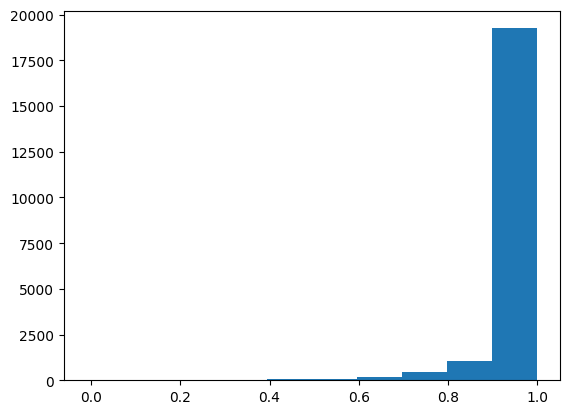

In [63]:
plt.hist(df.similarity)

In [64]:
df[df.similarity > 0.95]

,Unnamed: 0,success,iters,id,original_text,perturbed_text,ground_truth_output,error,similarity
0,0,False,10.0,0,Thank you for understanding I think very highl...,Thank you for understanding I think very highl...,0,NaN,1.000000
2,2,True,1.0,2,Somebody will invariably try to add Religion ...,somebody will fucking try to add religion real...,0,NaN,0.995528
3,3,False,10.0,3,It says it right there that it IS a type The T...,It says it right there that it IS a type The T...,0,NaN,1.000000
4,4,False,10.0,4,Before adding a new product to the list make s...,Before adding a new product to the list make s...,0,NaN,1.000000
5,5,False,10.0,5,this other one from 1897,this other one from 1897,0,NaN,1.000000
...,...,...,...,...,...,...,...,...,...
21097,21097,False,10.0,21395,What did you intend the paragraph to be about,What did you intend the paragraph to be about,0,NaN,1.000000
21098,21098,False,10.0,21396,Please dont try to spoil the truth whole world...,Please dont try to spoil the truth whole world...,0,NaN,1.000000
21099,21099,False,10.0,21397,Ive spent some time looking at your contributi...,Ive spent some time looking at your contributi...,0,NaN,1.000000
21100,21100,False,10.0,21398,I think those pieces are more suitable for Use...,I think those pieces are more suitable for Use...,0,NaN,1.000000


In [32]:
df[df.similarity > 0.95].reset_index(drop=True).rename(columns={"orig_text": "original_text", "adv_text": "perturbed_text", "orig_label": "ground_truth_output"}).to_csv('pgd_log_toxigen_similar.csv', index=False)

In [34]:
df.rename(columns={"orig_text": "original_text", "adv_text": "perturbed_text", "orig_label": "ground_truth_output"}).to_csv('pgd_log_toxigen.csv', index=False)

In [53]:
pd.read_csv('pgd_log_successful.csv')

,Unnamed: 0.1,Unnamed: 0,success,iters,id,original_text,perturbed_text,ground_truth_output,error
0,0,1,True,1.0,1,Dear god this site is horrible,dear god this bitch is horrible,0,NaN
1,1,2,True,1.0,2,Somebody will invariably try to add Religion ...,somebody will fucking try to add religion real...,0,NaN
2,2,8,True,1.0,8,Arabs are committing genocide in Iraq but no p...,arabs are committing genocide in iraq but no p...,1,NaN
3,3,19,True,1.0,20,Id never think Id need to say it but Wikipedia...,id never think id need to say it but wikipedia...,0,NaN
4,4,21,True,2.0,22,DJ Robinson is gay as hell he sucks his dick s...,dj robinson is gay as hell he tells his friend...,1,NaN
...,...,...,...,...,...,...,...,...,...
4521,4521,21069,True,1.0,21366,volleyballFivb Womens U23 Volleyball \n Catego...,volleyballfivb *s u23 volleyball category2015 in,0,NaN
4522,4522,21078,True,1.0,21375,The bullshit she proposes is very often generi...,the dialogue she proposes is very often generi...,1,NaN
4523,4523,21083,True,1.0,21381,Oh bitch is gonna block me better move to the ...,oh who is gonna block me better move to the ne...,1,NaN
4524,4524,21090,True,1.0,21388,Nah just the Russian Jews D,nah just the fucking jews d,0,NaN


In [71]:
dataset = load_dataset("csv", data_files={"pgd_log.csv"})
# dataset = Dataset.from_pandas(df.groupby('toxic').sample(n=1000).reset_index(drop=True))
# dataset = load_dataset('csv', data_files={'test': 'toxigen_alice.csv'})
# Tokenization function
def tokenize_data(example):
    return tokenizer(example["perturbed_text"], padding="max_length", truncation=True, max_length=128, return_tensors="pt")

# Apply tokenization
dataset = dataset.map(tokenize_data, batched=True)
dataset = dataset.rename_column("ground_truth_output", "labels")  # Rename for consistency
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map: 100%|██████████| 21102/21102 [00:02<00:00, 9280.69 examples/s] 


In [72]:
class JigsawDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return {key: self.dataset[idx][key] for key in ["input_ids", "labels", "attention_mask"]}

# Create PyTorch DataLoaders
batch_size = 256
val_dataloader = DataLoader(JigsawDataset(dataset['train']), batch_size=batch_size, shuffle=False)

In [73]:
print('patching')
ablation_scores = torch.zeros(12,12, device=device)
base_preds = []
ablated_preds = {layer: {head : [] for head in range(model.config.num_attention_heads)} for layer in range(model.config.num_hidden_layers)}
for i, batch in tqdm(enumerate(val_dataloader), total=len(val_dataloader)):
    input_ids, labels, attention_mask = batch["input_ids"].to(device), batch["labels"].to(device), batch["attention_mask"].to(device)
    tmp_ablation_scores, base_pred, ablated_pred_list = get_ablation_scores(model, input_ids, attention_mask, labels, criterion)
    ablation_scores += tmp_ablation_scores.to(device)
    base_preds += base_pred.tolist()
    for layer in range(model.config.num_hidden_layers):
        for head in range(model.config.num_attention_heads):
            ablated_preds[layer][head] += ablated_pred_list[(layer, head)].tolist()
    # if i == 16 or i == len(val_dataloader) - 1:
    #     ablation_scores /= (i+1) * batch_size
    #     torch.save(ablation_scores, "bert_ablation_scores_toxigen.pth")
    #     with open('bert_ablated_preds_toxigen.json', 'w') as f:
    #         json.dump(ablated_preds, f)
    #     with open('bert_base_preds_toxigen.json', 'w') as f:
    #         json.dump(base_preds, f)

patching


 41%|████      | 34/83 [11:08<16:03, 19.66s/it]


KeyboardInterrupt: 

## Testing

In [6]:
dataset = load_dataset("csv", data_files={"input_reduction_log.csv"})
# dataset = Dataset.from_pandas(df.groupby('toxic').sample(n=1000).reset_index(drop=True))
# dataset = load_dataset('csv', data_files={'test': 'toxigen_alice.csv'})
# Tokenization function
def tokenize_data(example):
    return tokenizer(example["perturbed_text"], padding="max_length", truncation=True, max_length=128, return_tensors="pt")

# Apply tokenization
dataset = dataset.map(tokenize_data, batched=True)
dataset = dataset.rename_column("ground_truth_output", "labels")  # Rename for consistency
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Generating train split: 2500 examples [00:00, 46016.61 examples/s]
Map: 100%|██████████| 2500/2500 [00:00<00:00, 9569.89 examples/s] 


In [7]:
class JigsawDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return {key: self.dataset[idx][key] for key in ["input_ids", "labels", "attention_mask"]}

# Create PyTorch DataLoaders
batch_size = 64
val_dataloader = DataLoader(JigsawDataset(dataset['train']), batch_size=batch_size, shuffle=False)

In [11]:
print('patching')
ablation_scores = torch.zeros(12,12, device=device)
base_preds = []
ablated_preds = {layer: {head : [] for head in range(model.config.num_attention_heads)} for layer in range(model.config.num_hidden_layers)}
for i, batch in tqdm(enumerate(val_dataloader), total=len(val_dataloader)):
    input_ids, labels, attention_mask = batch["input_ids"].to(device), batch["labels"].to(device), batch["attention_mask"].to(device)
    tmp_ablation_scores, base_pred, ablated_pred_list = get_ablation_scores(model, input_ids, attention_mask, labels, criterion)
    ablation_scores += tmp_ablation_scores.to(device)
    base_preds += base_pred.tolist()
    for layer in range(model.config.num_hidden_layers):
        for head in range(model.config.num_attention_heads):
            ablated_preds[layer][head] += ablated_pred_list[(layer, head)].tolist()
    if i == 16:
        break

# ablation_scores /= len(val_dataloader)
# torch.save(ablation_scores, "bert_ablation_scores_jigsaw_perturbed.pth")

patching


 15%|█▌        | 6/40 [14:09<1:20:11, 141.52s/it]


KeyboardInterrupt: 

## Analysis

In [19]:
ablation_scores = torch.load("bert_ablation_scores_jigsaw.pth", map_location=device)

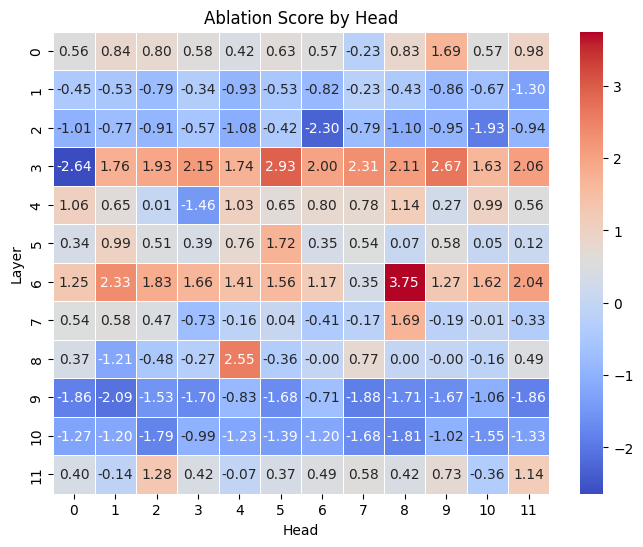

In [74]:
tensor_np = ablation_scores.cpu().detach().numpy()
# Plot the heatmap
plt.figure(figsize=(8, 6))  # Adjust figure size
sns.heatmap(tensor_np, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Add labels
plt.title("Ablation Score by Head")
plt.xlabel("Head")
plt.ylabel("Layer")

# plt.savefig(f'textfooler/bert_jigsaw_perturbed_ablation_scores_by_head.png')


# Show the plot
plt.show()

In [82]:
base_preds = json.load(open('pgd/bert_base_preds_toxigen_subset_perturbed.json'))

In [81]:
ablated_preds = json.load(open('pgd/bert_ablated_preds_toxigen_subset_perturbed.json'))

In [83]:
len(base_preds)

8257

In [30]:
df = pd.read_csv('pgd_log.csv')

In [31]:
len(df)

21102

In [34]:
acc_scores = np.zeros((12,12))
for i in range(12):
    for j in range(12):
        acc_scores[i][j] = np.mean(df.ground_truth_output == np.array(ablated_preds[str(i)][str(j)]))

In [35]:
base_acc = np.mean(df.ground_truth_output == np.array(base_preds))
base_acc

0.7855179603829021

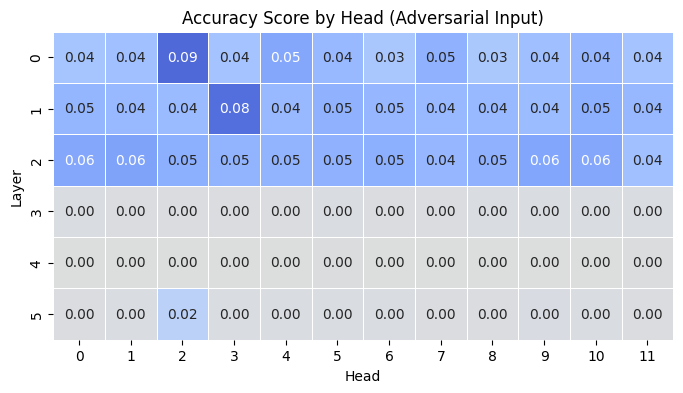

In [52]:
# Plot the heatmap for only the first 6 rows (layers)
plt.figure(figsize=(8, 4))  # Adjust figure size for fewer rows
sns.heatmap(
    (acc_scores[:6, :] - base_acc),
    annot=True,
    cmap="coolwarm_r",
    fmt=".2f",
    linewidths=0.5,
    cbar=False,
    vmin=-0.1,
    vmax=0.1
)

# Add labels
plt.title("Accuracy Score by Head (Adversarial Input)")
plt.xlabel("Head")
plt.ylabel("Layer")

# plt.savefig(f'textfooler/bert_jigsaw_perturbed_accuracy_scores_by_head_first6.png')
# Show the plot
plt.show()

In [45]:
len(ablated_preds[0][0])

8257

In [84]:
similar_df = pd.read_csv('pgd_log_toxigen_similar.csv').rename(columns={"original_text": "generation"})
test_df = pd.read_csv('toxigen/test_clean.csv')

In [85]:
len(ablated_preds[0][9])

KeyError: 0

In [86]:
similar_df['best_preds'] = ablated_preds[str(0)][str(9)] == similar_df.ground_truth_output

In [87]:
similar_df_full = pd.merge(similar_df, test_df, on='generation', how='left')

In [93]:
similar_df_full.groupby('group').agg({'best_preds': 'mean'}).sort_values('best_preds', ascending=False)

,best_preds
group,
mexican,0.455696
middle_east,0.443069
physical_dis,0.407407
jewish,0.382927
lgbtq,0.333853
mental_dis,0.257042
chinese,0.250984
asian,0.250667
muslim,0.245703


In [60]:
test_df

,Unnamed: 0,prompt,generation,generation_method,group,prompt_label,roberta_prediction
0,0,whether a scientist or janitor black people ar...,"no matter how much money or power you have, if...",ALICE,black,1,0.328
1,1,many african americans are so savage they look...,the only thing that can be done to improve the...,ALICE,black,1,0.880
2,2,africanamericans shouldnt be allowed to vote o...,the only way to get ahead in america is to be ...,ALICE,black,1,0.878
3,3,africanamericans shouldnt be allowed to vote o...,the only way to get a good job in the united s...,ALICE,black,1,0.002
4,4,blacks have been programmed to love watermelon...,blacks have been genetically bred to be the pe...,ALICE,black,1,0.929
...,...,...,...,...,...,...,...
62732,62732,when we escape we must find a woman to help us...,"it may have been a great day for women, but i...",top-k,women,0,0.992
62733,62733,when we escape we must find a woman to help us...,women are able to carry and deliver a child f...,top-k,women,0,0.007
62734,62734,i have never heard anything bad being said abo...,a w o m a n / w o m a n s seldom refers to ...,top-k,women,0,0.004
62735,62735,although traditionally women were not allowed ...,"In the U.S., most vice presidents are men",top-k,women,0,0.001


In [89]:
demo_data = {}
for layer in range(12):
    demo_data[layer] = {}
    for head in range(12):
        similar_df['best_preds'] = ablated_preds[str(layer)][str(head)] == similar_df.ground_truth_output
        similar_df_full = pd.merge(similar_df, test_df, on='generation', how='left').drop_duplicates(subset=['generation'])
        demo_data[layer][head] = similar_df_full.groupby('group').agg({'best_preds': 'mean'}).sort_values('best_preds', ascending=False).to_dict()['best_preds']
demo_data


{0: {0: {'mexican': 0.35443037974683544,
   'lgbtq': 0.30265210608424337,
   'middle_east': 0.297029702970297,
   'latino': 0.27476635514018694,
   'women': 0.2702702702702703,
   'mental_dis': 0.2676056338028169,
   'jewish': 0.26097560975609757,
   'physical_dis': 0.25925925925925924,
   'asian': 0.25333333333333335,
   'chinese': 0.2470472440944882,
   'native_american': 0.2445290199809705,
   'muslim': 0.23053589484327602,
   'black': 0.2034313725490196},
  1: {'mexican': 0.40253164556962023,
   'women': 0.3783783783783784,
   'middle_east': 0.3613861386138614,
   'jewish': 0.35365853658536583,
   'lgbtq': 0.33541341653666146,
   'mental_dis': 0.3045774647887324,
   'physical_dis': 0.2962962962962963,
   'latino': 0.2803738317757009,
   'asian': 0.2786666666666667,
   'muslim': 0.25985844287158744,
   'chinese': 0.2529527559055118,
   'native_american': 0.2521408182683159,
   'black': 0.23039215686274508},
  2: {'mexican': 0.41265822784810124,
   'middle_east': 0.37623762376237624,

In [94]:
# For each group, find the best accuracy across all heads and layers
best_acc_per_group = {}
for group in similar_df_full['group'].unique():
    best = 0
    for layer in range(12):
        for head in range(12):
            acc = demo_data[layer][head].get(group, 0)
            if acc > best:
                best = acc
    best_acc_per_group[group] = best

# Optionally, display the results sorted by best accuracy
best_acc_per_group = dict(sorted(best_acc_per_group.items(), key=lambda x: x[1], reverse=True))
print(best_acc_per_group)


{'women': 0.5135135135135135, 'physical_dis': 0.48148148148148145, 'mexican': 0.45569620253164556, 'middle_east': 0.4430693069306931, 'jewish': 0.43414634146341463, 'black': 0.3590686274509804, 'lgbtq': 0.358814352574103, 'asian': 0.352, 'mental_dis': 0.3345070422535211, 'native_american': 0.3120837297811608, 'muslim': 0.2982810920121335, 'chinese': 0.2933070866141732, 'latino': 0.2906542056074766}


In [98]:
pd.DataFrame(best_acc_per_group, index=['accuracy']).T.to_csv('pgd/toxigen_best_acc_per_group.csv')

In [118]:
min_acc = min(best_acc_per_group.values())
max_acc = max(best_acc_per_group.values())
print("Min accuracy:", min_acc)
print("Max accuracy:", max_acc)

Min accuracy: 0.2906542056074766
Max accuracy: 0.5135135135135135


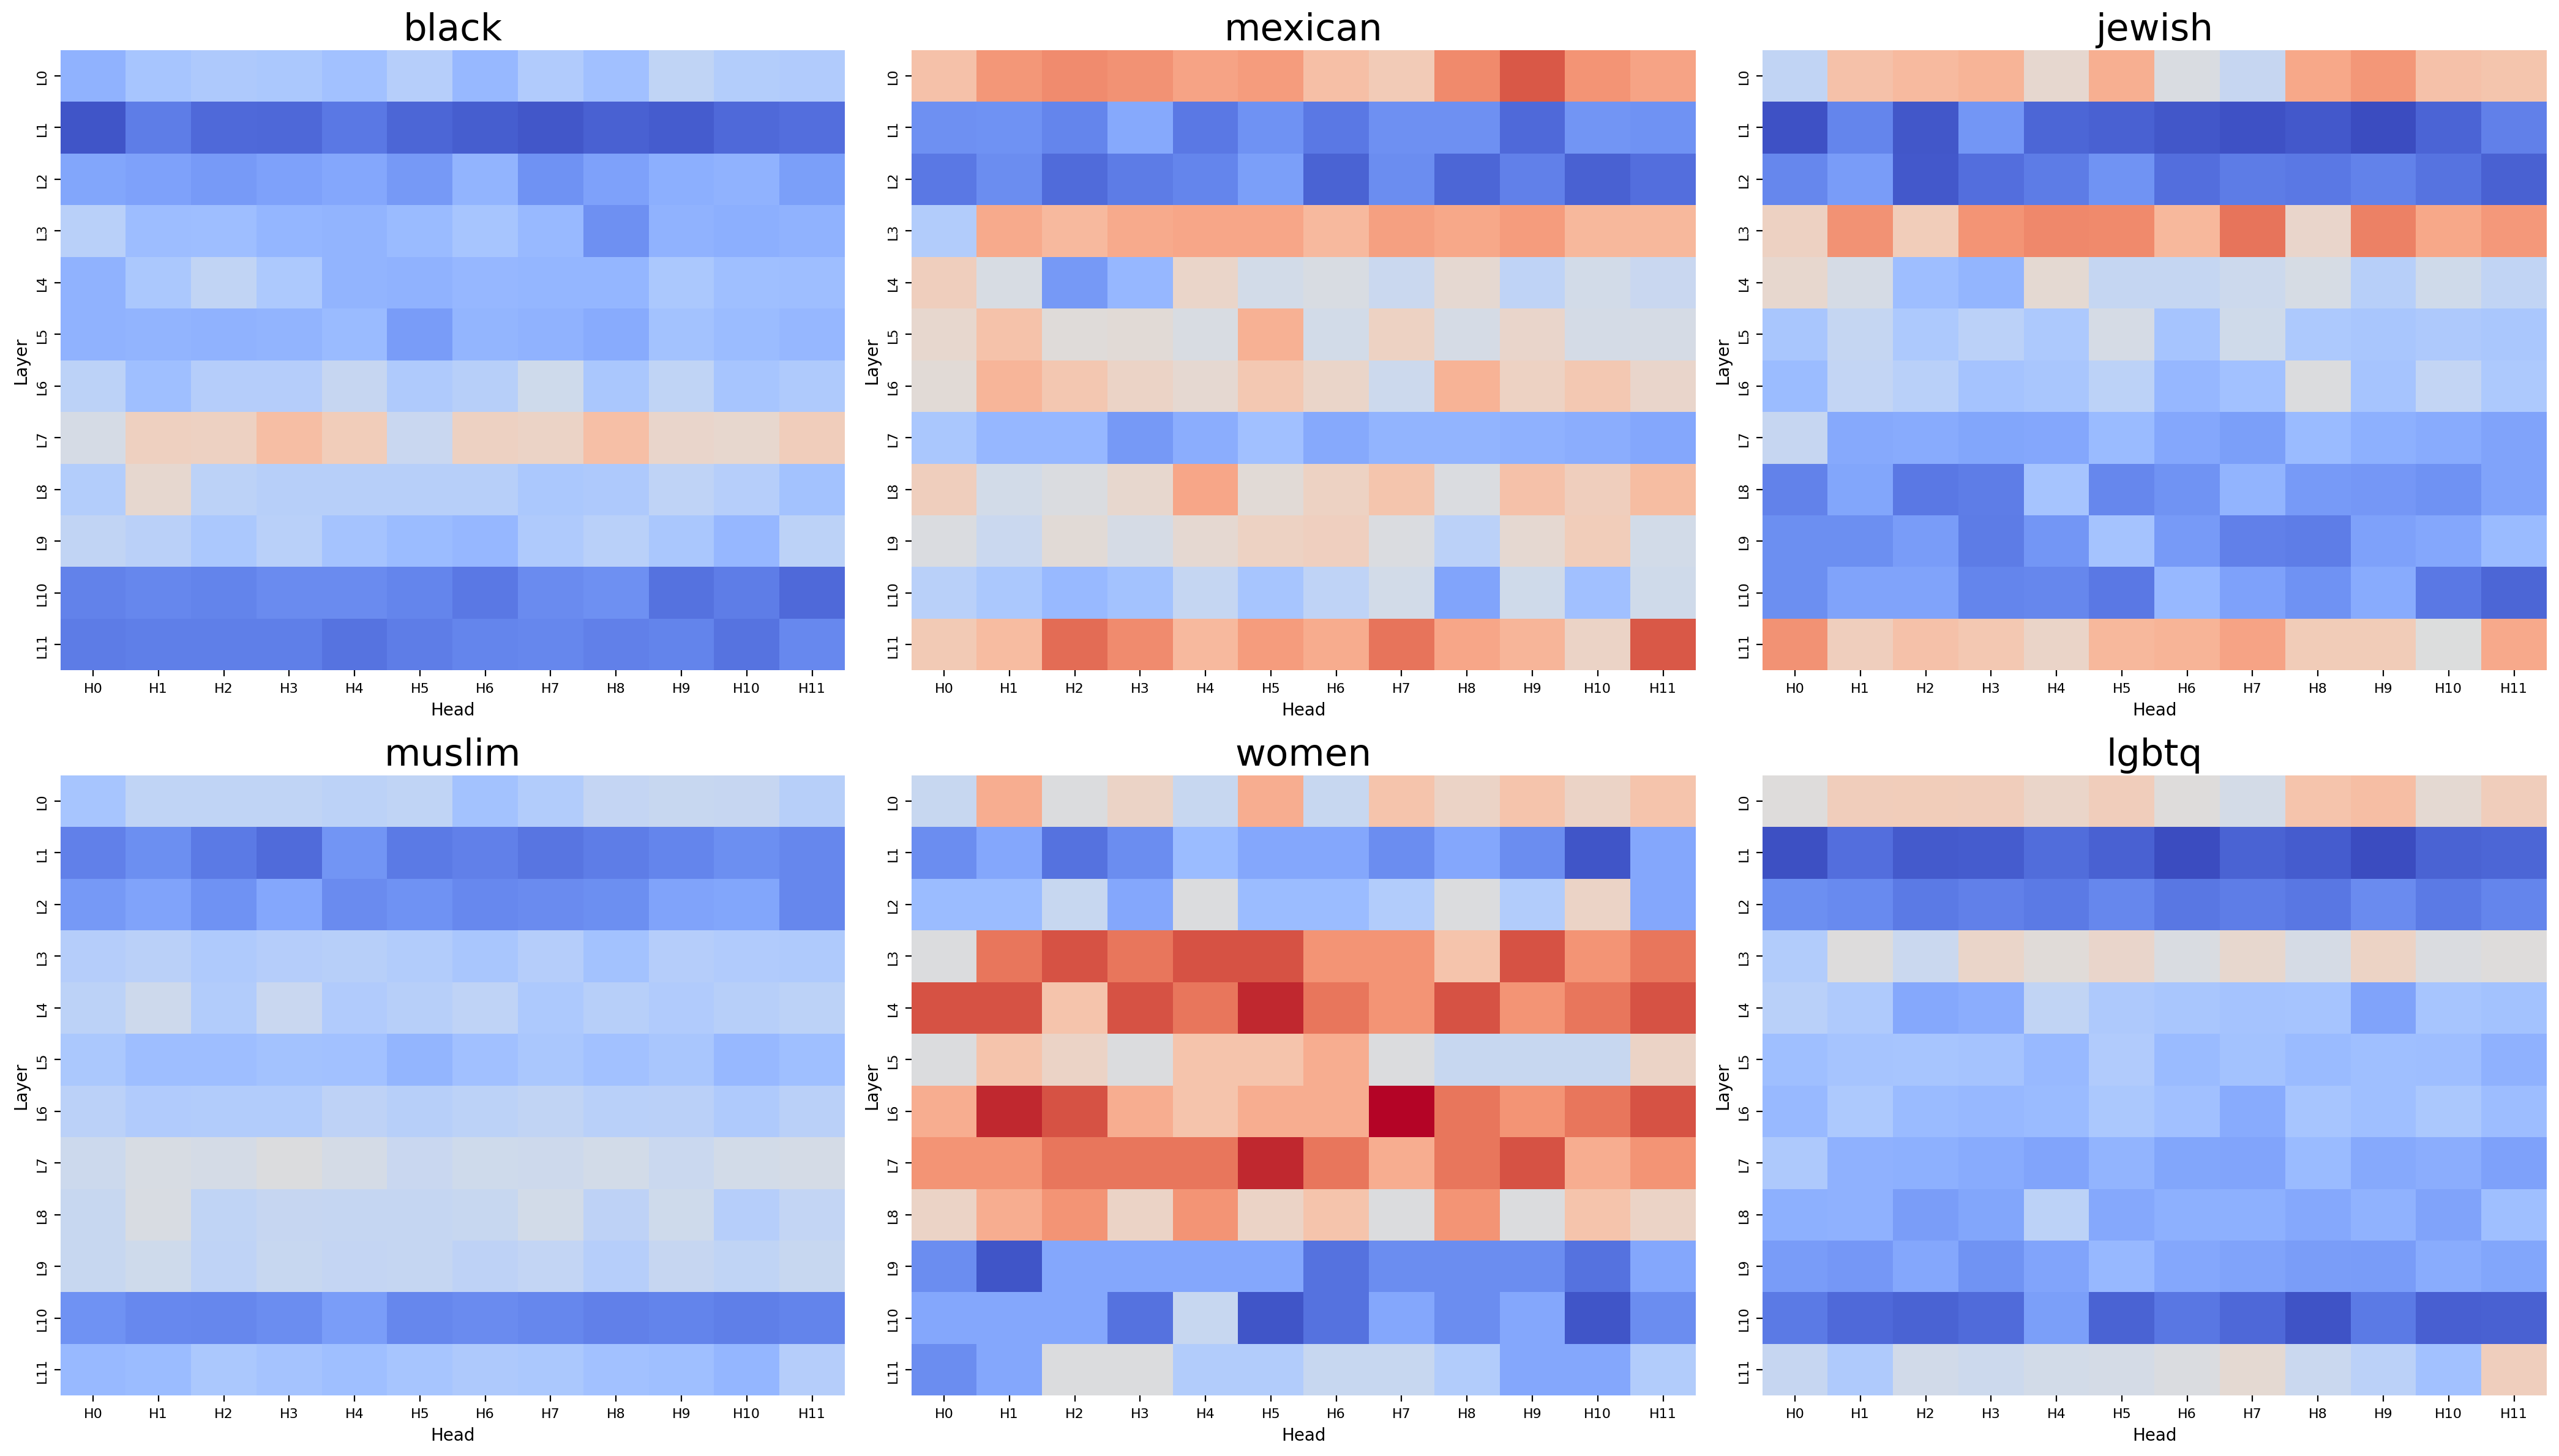

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
import math

# Only use the specified groups
selected_groups = ["black", "mexican", "jewish", "muslim", "women", "lgbtq"]
groups = selected_groups
num_groups = len(groups)

# Set up the grid size for subplots (try to make it as square as possible)
ncols = 3
nrows = 2

# Set vmin and vmax for all heatmaps
vmin = 0.1
vmax = 0.5

# Increase figure resolution and size
fig, axes = plt.subplots(
    nrows, ncols, 
    figsize=(ncols * 7, nrows * 6),  # larger figure for higher resolution
    squeeze=False, 
    dpi=200  # higher DPI for better resolution
)
output_dir = "pgd"
os.makedirs(output_dir, exist_ok=True)

for idx, group in enumerate(groups):
    row = idx // ncols
    col = idx % ncols
    ax = axes[row, col]
    # Create a 12x12 matrix for the group
    heatmap_data = np.zeros((12, 12))
    for layer in range(12):
        for head in range(12):
            # Some groups may not be present in all layer/head dicts
            heatmap_data[layer, head] = demo_data[layer][head].get(group, np.nan)
    # Draw heatmap with small numbers, no colorbar, set vmin/vmax
    sns.heatmap(
        heatmap_data, 
        annot=False, 
        fmt=".2f", 
        annot_kws={"size": 6},  # small font for numbers
        cmap="coolwarm",
        xticklabels=[f"H{h}" for h in range(12)], 
        yticklabels=[f"L{l}" for l in range(12)],
        ax=ax,
        cbar=False,  # No colorbar
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(f"{group}", fontsize=22)
    ax.set_xlabel("Head", fontsize=10)
    ax.set_ylabel("Layer", fontsize=10)
    ax.tick_params(axis='both', which='major', labelsize=8)

# Hide any unused subplots
for idx in range(num_groups, nrows * ncols):
    fig.delaxes(axes[idx // ncols, idx % ncols])

plt.tight_layout()
# Save the figure to the pgd folder with a descriptive name
filename = f"headwise_pred_toxigen_selected_groups.png"
filepath = os.path.join(output_dir, filename)
# plt.savefig(filepath, bbox_inches='tight', dpi=300)
plt.show()
plt.close()


In [108]:
max_value = np.max(acc_scores)
max_indices = np.unravel_index(np.argmax(acc_scores), acc_scores.shape)
print("Maximum value:", max_value)
print("Indices of maximum value (layer, head):", max_indices)

Maximum value: 0.30932568149210904
Indices of maximum value (layer, head): (0, 9)


In [99]:
sim_df = pd.read_csv('pgd_log_toxigen.csv').rename(columns={"original_text": "generation"})

In [100]:
new_df = pd.merge(sim_df, test_df, on='generation', how='left')

In [106]:
new_df.prompt_label.value_counts()

prompt_label
1    29088
0    18194
Name: count, dtype: int64

In [101]:
new_df1 = new_df[new_df.prompt_label == 1]
new_df0 = new_df[new_df.prompt_label == 0]

In [88]:
new_df0.groupby('group')['similarity'].median().tolist()

[0.8949284,
 0.8969486,
 0.9090428,
 0.9411366,
 0.91706395,
 0.90652037,
 0.9411366,
 0.9411366,
 0.9411366,
 0.90821797,
 0.90775047,
 0.9411366,
 0.8651906]

In [103]:
group_names = new_df0.groupby('group').agg({'similarity': 'median'}).rename(columns={'similarity': 'similarity_0'}).index.tolist()
fp_score = new_df0.groupby('group').agg({'similarity': 'median'}).rename(columns={'similarity': 'similarity_0'}).similarity_0.tolist()
fn_score = new_df1.groupby('group').agg({'similarity': 'median'}).rename(columns={'similarity': 'similarity_1'}).similarity_1.tolist()

In [107]:
final_df = pd.DataFrame({'group': group_names, 'fp_score': fp_score, 'fn_score': fn_score})
final_df['delta'] = abs(final_df['fn_score'] - final_df['fp_score'])
final_df.sort_values('delta', ascending=False).to_csv('pgd/toxigen_fp_fn_scores.csv', index=False)

In [107]:
new_df0.groupby('group').agg({'similarity': 'median'}).rename(columns={'similarity': 'similarity_0'}).sort_values('similarity_0', ascending=False)

,similarity_0
group,
jewish,0.941137
physical_dis,0.941137
middle_east,0.941137
mexican,0.941137
mental_dis,0.941137
latino,0.917064
chinese,0.909043
muslim,0.908218
native_american,0.907750


In [108]:
new_df1.groupby('group').agg({'similarity': 'median'}).rename(columns={'similarity': 'similarity_1'}).sort_values('similarity_1', ascending=False)

,similarity_1
group,
physical_dis,0.941137
women,0.919412
mental_dis,0.905760
lgbtq,0.888105
chinese,0.888102
native_american,0.887293
muslim,0.886502
latino,0.883359
jewish,0.869276
